# Scenario 1 — Model Selection & Justification

## Why These Models?

The dataset consists of **442 patients** and **6 retained features** after 
EDA-based feature reduction (AGE, SEX, BMI, BP, S3, S5). The relatively 
small sample size and low dimensionality are key factors in the model 
selection decision.

## What the Data Told Us

The EDA shaped the model selection in three concrete ways:

- **Residual multicollinearity** (S5 VIF: 77.4) rules out naive linear 
  models — L2 regularization or tree-based approaches are needed to 
  prevent unstable coefficients
- **Balanced classes** (54/46 split) mean no resampling is required — 
  both models can be trained on the data as-is
- **No Y outliers** confirmed by IQR analysis — both thresholds are 
  applied to clean, representative patient data

## The Models

**Logistic Regression** was selected as the first model — well suited for 
balanced binary classification with L2 regularization applied to handle 
residual multicollinearity. Requires the mean centered dataset since 
feature scaling is essential for stable coefficient estimation.

**Random Forest** was selected as the second model — handles 
multicollinearity naturally and captures non-linear relationships. 
Uses the original dataset since tree splits on real-world values 
are more interpretable and scaling provides no benefit.

Both models are compared to determine which better classifies 
patients at risk of diabetes progression above the 150 threshold.

## How We Evaluate

Accuracy alone is misleading in a medical context. A model that predicts 
"Not At Risk" for every patient would achieve 54% accuracy while being 
completely useless. Instead both models are evaluated on **precision, 
recall, F1-score and AUC-ROC**. Recall for the positive class is the 
most clinically important metric — missing a patient who is truly at risk 
carries a higher cost than incorrectly flagging a healthy one.

## 2. Import neccesary libraries for evaulating and building

In [1]:
# Data handling
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
import warnings as wr
wr.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Logistic Regression

The mean centered dataset is used here since Logistic Regression requires 
features to be on the same scale for stable coefficient estimation. 
Without scaling, features with larger ranges like AGE (19-79) would 
dominate over features with smaller ranges like S5 (3.5-6.0), distorting 
the learned weights regardless of actual predictive importance.

A `StandardScaler` is applied **after** the train/test split to prevent 
data leakage — the scaler learns the mean and standard deviation from the 
training set only, then applies the same transformation to the test set.

In [2]:
# Features we need based on EDA 
features_scaled = ["age", "sex", "bmi", "bp", "s3", "s5"]

# We load the mean centered dataset for Logistic Regression
diabetes_data = load_diabetes()
df_mean_centered = pd.DataFrame(diabetes_data.data, columns=diabetes_data.feature_names)
df_mean_centered["y"] = diabetes_data.target
df_mean_centered["y"] = df_mean_centered["y"].astype("Int64")
df_mean_centered = df_mean_centered[features_scaled + ["y"]]       

print(f"Shape of the dataset: {df_mean_centered.shape}")
df_mean_centered.sample(5)

Shape of the dataset: (442, 7)


,age,sex,bmi,bp,s3,s5,y
61,-0.041840,0.050680,0.004572,-0.053870,-0.080217,0.036644,144
220,0.023546,0.050680,-0.039618,-0.005670,0.011824,-0.101640,78
39,-0.001882,0.050680,0.014272,-0.074527,-0.013948,0.019196,90
344,-0.107226,-0.044642,-0.011595,-0.040099,-0.013948,0.007027,200
348,0.030811,-0.044642,-0.020218,-0.005670,0.078093,-0.010903,148


In [3]:
# Switch out the data for binary classification based on treshold 1
df_mean_centered["y"] = (df_mean_centered["y"] >= 150).astype(int)
print(df_mean_centered.sample(5))

# Create the X and Y variables and splitting them to test and train variables
X_scaled = df_mean_centered[features_scaled]
print(X_scaled.sample(5))
y = df_mean_centered["y"]

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nLogistic Regression — Train: {X_train_lr.shape}, Test: {X_test_lr.shape}")
print("\nLR Train balance:")
print(y_train_lr.value_counts(normalize=True).round(3))

          age       sex       bmi        bp        s3        s5  y
69   0.016281 -0.044642 -0.046085 -0.005670 -0.013948 -0.051404  1
420  0.023546 -0.044642 -0.036385  0.000079 -0.043401 -0.033246  0
15  -0.052738  0.050680 -0.018062  0.080401 -0.039719  0.036060  1
246  0.041708 -0.044642 -0.032073 -0.061892  0.056003  0.045067  0
106 -0.096328 -0.044642 -0.076264 -0.043542  0.008142 -0.059471  0
          age       sex       bmi        bp        s3        s5
389 -0.005515  0.050680  0.001339 -0.084856  0.048640 -0.041176
188  0.005383 -0.044642 -0.002973  0.049415  0.044958 -0.001496
124 -0.005515 -0.044642  0.023973  0.008101  0.022869 -0.015999
320 -0.023677 -0.044642  0.030440 -0.005670 -0.017629  0.033043
88  -0.052738  0.050680 -0.040696 -0.067642  0.037595 -0.034522

Logistic Regression — Train: (353, 6), Test: (89, 6)

LR Train balance:
y
0    0.538
1    0.462
Name: proportion, dtype: float64


In [4]:
scaler = StandardScaler()
X_train_lr = pd.DataFrame(scaler.fit_transform(X_train_lr), columns=features_scaled)
X_test_lr = pd.DataFrame(scaler.transform(X_test_lr), columns=features_scaled)

lr_model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_train_lr, y_train_lr)
print("Logistic Regression model finished training")

Logistic Regression model finished training


## 4. Random Forest

The original dataset is used since tree-based models are scale-invariant 
and splits on real-world values (e.g. BMI > 28) are more interpretable 
than scaled equivalents. No feature scaling is applied.

No scaling is applied. Depth is constrained (max_depth=5, 
min_samples_leaf=5) to prevent overfitting on the small dataset.

In [5]:
# Features we need based on EDA 
features_original = ["AGE", "SEX", "BMI", "BP", "S3", "S5"]

# If viewed on mac to bypass SSL cert problem:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

original_data_url = "https://www4.stat.ncsu.edu/~boos/var.select/diabetes.tab.txt"

df_original_data = pd.read_csv(original_data_url, sep="\t")
df_original_data = df_original_data[features_original + ["Y"]]       

print(f"Shape of the dataset: {df_original_data.shape}")
df_original_data.sample(5)

Shape of the dataset: (442, 7)


,AGE,SEX,BMI,BP,S3,S5,Y
406,33,1,18.9,70.0,59.0,4.0254,72
22,25,1,26.0,92.0,56.0,3.9703,68
187,30,1,21.3,87.0,63.0,3.6889,143
401,53,1,22.2,78.0,70.0,4.1744,93
429,37,1,23.3,88.0,65.0,4.3567,94


In [6]:
# Switch out the data for binary classification based on treshold 1
df_original_data["Y"] = (df_original_data["Y"] >= 150).astype(int)
print(df_original_data.sample(5))

# Create the X and Y variables and splitting them to test and train variables
X = df_original_data[features_original]
y_tree = df_original_data["Y"]

X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X, y_tree,
    test_size=0.2,
    random_state=42,
    stratify=y_tree
)

print(f"\nTree models — Train: {X_train_tree.shape}, Test: {X_test_tree.shape}")
print("\nTree Train balance:")
print(y_train_tree.value_counts(normalize=True).round(3))

     AGE  SEX   BMI      BP    S3      S5  Y
419   43    1  21.3   79.00  53.0  3.8286  0
265   39    2  24.0   89.67  52.0  4.8040  0
291   69    1  28.1  113.00  52.0  5.2781  1
372   41    2  24.2   90.00  57.0  4.5218  0
57    41    1  20.5   80.00  64.0  4.0254  0

Tree models — Train: (353, 6), Test: (89, 6)

Tree Train balance:
Y
0    0.538
1    0.462
Name: proportion, dtype: float64


In [7]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)

rf_model.fit(X_train_tree, y_train_tree)
print("Random Forest model finished training ")

Random Forest model finished training 


## 5. Evaluating model and visualazing

Both models are evaluated on the same test set using precision, recall, 
F1-score and AUC-ROC.

In [8]:
# Logistic Regression model evaulation
y_pred_lr = lr_model.predict(X_test_lr)
y_prob_lr = lr_model.predict_proba(X_test_lr)[:, 1]

print("=" * 50)
print("LOGISTIC REGRESSION — Classification Report")
print("=" * 50)
print(classification_report(y_test_lr, y_pred_lr, target_names=["Not At Risk", "At Risk"]))

LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

 Not At Risk       0.73      0.69      0.71        48
     At Risk       0.66      0.71      0.68        41

    accuracy                           0.70        89
   macro avg       0.70      0.70      0.70        89
weighted avg       0.70      0.70      0.70        89



In [9]:
# Random Forest model evaulation
y_pred_rf = rf_model.predict(X_test_tree)
y_prob_rf = rf_model.predict_proba(X_test_tree)[:, 1]

print("=" * 50)
print("RANDOM FOREST — Classification Report")
print("=" * 50)
print(classification_report(y_test_tree, y_pred_rf, target_names=["Not At Risk", "At Risk"]))

RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

 Not At Risk       0.71      0.71      0.71        48
     At Risk       0.66      0.66      0.66        41

    accuracy                           0.69        89
   macro avg       0.68      0.68      0.68        89
weighted avg       0.69      0.69      0.69        89



In [14]:
# Cross-validation check
from sklearn.model_selection import cross_val_score

lr_cv = cross_val_score(lr_model, X_train_lr, y_train_lr, cv=5, scoring='roc_auc')
rf_cv = cross_val_score(rf_model, X_train_tree, y_train_tree, cv=5, scoring='roc_auc')

print(f"LR Cross-val AUC: {lr_cv.mean():.3f} (+/- {lr_cv.std():.3f})")
print(f"RF Cross-val AUC: {rf_cv.mean():.3f} (+/- {rf_cv.std():.3f})")

LR Cross-val AUC: 0.851 (+/- 0.032)
RF Cross-val AUC: 0.831 (+/- 0.037)


Both models achieved comparable performance on the 89-patient test set. 
Logistic Regression marginally outperformed Random Forest with 70% vs 69% 
accuracy and more importantly a higher at-risk recall of 0.71 vs 0.66 — 
meaning it correctly identifies more at-risk patients.

This is further confirmed by cross-validated AUC of 0.851 (±0.032) vs 
0.831 (±0.037)

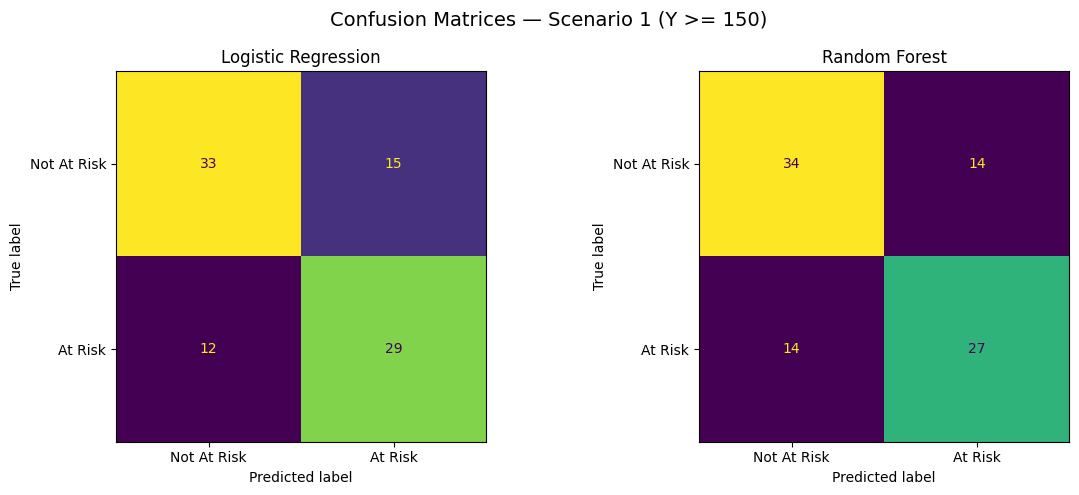

In [10]:
# Creating the Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Confusion Matrices — Scenario 1 (Y >= 150)", fontsize=14)

ConfusionMatrixDisplay(confusion_matrix(y_test_lr, y_pred_lr),
                       display_labels=["Not At Risk", "At Risk"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(confusion_matrix(y_test_tree, y_pred_rf),
                       display_labels=["Not At Risk", "At Risk"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

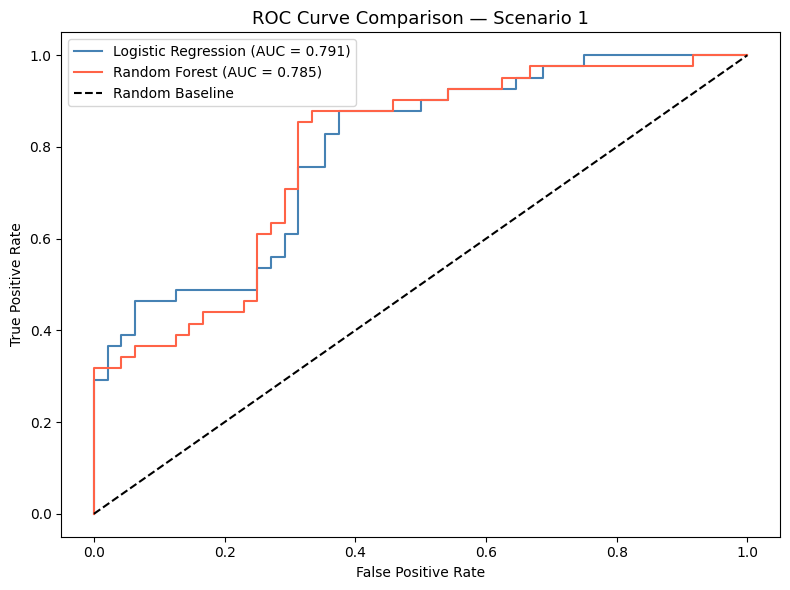

In [11]:
# Checking the ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))

fpr_lr, tpr_lr, _ = roc_curve(y_test_lr, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test_tree, y_prob_rf)

ax.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test_lr, y_prob_lr):.3f})", color="steelblue")
ax.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test_tree, y_prob_rf):.3f})", color="tomato")
ax.plot([0, 1], [0, 1], "k--", label="Random Baseline")

ax.set_title("ROC Curve Comparison — Scenario 1", fontsize=13)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

Logistic Regression correctly identified 29 out of 41 at-risk patients 
while missing 12. Random Forest identified 27 out of 41 while missing 14. 
Both models produce a similar number of false positives (15 and 14) where 
healthy patients are incorrectly flagged as at-risk.

The ROC curves confirm this — Logistic Regression achieves AUC 0.791 vs 
Random Forest 0.785, both well above the 0.5 random baseline. The cross-validated 
AUC further widens this gap (0.851 vs 0.831), confirming Logistic Regression 
generalises more consistently across different data splits.

Logistic Regression is the stronger model for Scenario 1 on every metric — 
higher AUC, fewer missed at-risk patients and more stable cross-validation performance.

LOGISTIC REGRESSION — Feature Coefficients
Feature  Coefficient
     s5     0.835316
     bp     0.742708
    bmi     0.606476
    sex    -0.481523
     s3    -0.352625
    age     0.061544


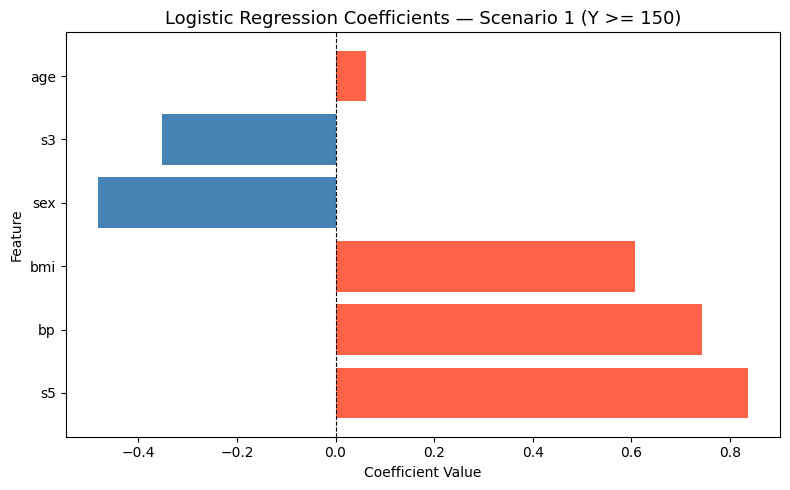

In [15]:
# Feature coefficients for logistic reg
coef_df = pd.DataFrame({
    "Feature": features_scaled,
    "Coefficient": lr_model.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)

print("=" * 45)
print("LOGISTIC REGRESSION — Feature Coefficients")
print("=" * 45)
print(coef_df.to_string(index=False))

# Visualize the data
fig, ax = plt.subplots(figsize=(8, 5))

colors = ["tomato" if c > 0 else "steelblue" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Logistic Regression Coefficients — Scenario 1 (Y >= 150)", fontsize=13)
ax.set_xlabel("Coefficient Value")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

## 6. Conclusion — Scenario 1 (Y >= 150)

Logistic Regression outperformed Random Forest across all evaluation metrics, 
achieving a cross-validated AUC of 0.851 (±0.032) and correctly identifying 
more at-risk patients (29 vs 27). The feature coefficients directly confirmed 
the EDA findings — S5, BP and BMI emerged as the strongest positive predictors 
while S3 (HDL) confirmed its protective role with a negative coefficient, 
exactly as the correlation analysis suggested.

The 70% accuracy ceiling is not a modeling failure but a reflection of the 
dataset's information limits. Diabetes progression is heavily influenced by 
factors not captured here — genetics, lifestyle, diet, medication and 
longitudinal trends. These unmeasured variables are the primary driver of 
the unexplained variance that neither model can overcome regardless of tuning.

For future improvement, enriching the feature set with lifestyle and genetic 
data would likely push performance significantly beyond the current ceiling. 
At that point, a more complex model such as XGBoost or a gradient boosting 
approach would be justified by both the increased data volume and 
dimensionality.